In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
%matplotlib inline

rng = np.random.default_rng()

# Testing stuff

In [2]:
g = ig.Graph.Lattice([5, 5], circular=False)
adj_list = g.get_adjlist()
n_edges = g.ecount()
n_nodes = g.vcount()

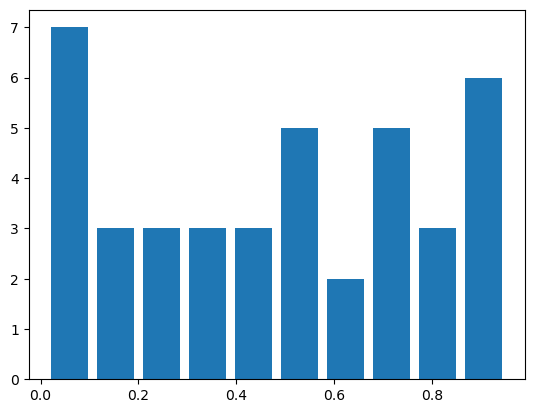

In [9]:
link_prob = rng.uniform(0, 1, n_edges)
counts, edges, _ = plt.hist(link_prob, rwidth=0.8)
is_percolating = rng.random(n_edges) < link_prob

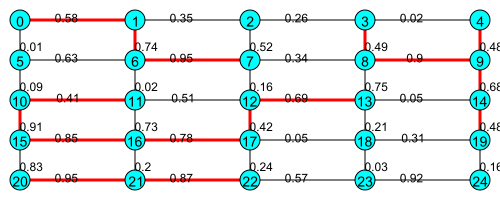

In [10]:
ig.plot(
    g,
    layout="grid",
    bbox=(500, 200),
    vertex_label=g.vs.indices,
    vertex_color="cyan",
    edge_width=[3 if is_percolating[e] else 1 for e in g.es.indices],
    edge_color=["red" if is_percolating[e] else "black" for e in g.es.indices],
    edge_label=np.around(link_prob, 2)
)

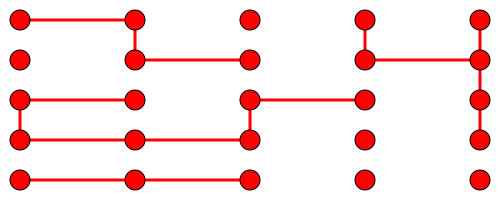

In [11]:
work = g.copy()
links_to_remove = np.flatnonzero(~is_percolating)
work.delete_edges(links_to_remove)
ig.plot(work, layout="grid", bbox=(500, 200), edge_width=3, edge_color="red")

In [33]:
%%timeit
work.components().giant().vcount()

13.8 µs ± 289 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [34]:
%%timeit
max(work.components().sizes())

5.27 µs ± 183 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Function

In [42]:
def simulate(graph, window=0, n_probs=100, copies=100, low_p=0.4, high_p=0.6, no_bar=False):
    n_edges = g.ecount()
    lcc = np.zeros(n_probs, dtype="float32")
    all_prob = np.linspace(low_p, high_p, n_probs)
    for idx, p in tqdm(enumerate(all_prob), total=n_probs, disable=no_bar):
        is_removed = rng.random((copies, n_edges))
        link_prob = rng.uniform(
            max(p - window, 0), min(p + window, 1), (copies, n_edges)
        )
        # link_prob = np.repeat(link_prob, copies, axis=0)
        links_removed = is_removed >= link_prob
        for rep in range(copies):
            links_to_remove = np.flatnonzero(links_removed[rep])
            work = graph.copy()
            work.delete_edges(links_to_remove)
            lcc[idx] += max(work.components().sizes())
            # lcc[idx] += work.components().size(0)
            # ANOTHER ORDER PARAMETER???
        lcc[idx] /= copies
    return all_prob, lcc / g.vcount()

In [85]:
g = ig.Graph.Lattice([1000, 1000], circular=False)

In [86]:
prob, my_lcc = simulate(g, copies=20, n_probs=30, low_p=0, high_p=1)

  0%|          | 0/30 [00:00<?, ?it/s]

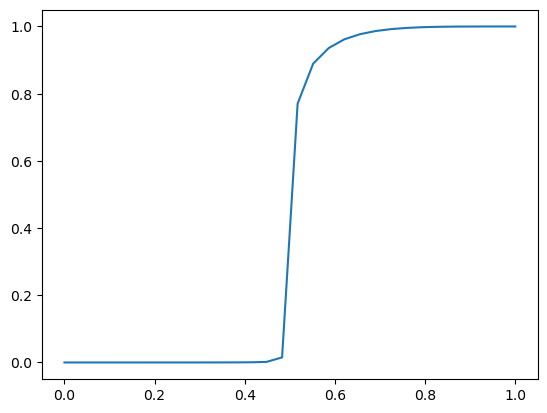

In [87]:
plt.plot(prob, my_lcc)

In [22]:
lcc = []
windows = np.linspace(0, 0.5, 11)
for win in tqdm(windows):
    prob, temp = simulate(g, window=win, no_bar=True, n_probs=50, copies=100)
    lcc.append(temp)
# np.savetxt("results.txt", lcc)

  0%|          | 0/11 [00:00<?, ?it/s]

(0.4, 0.6)

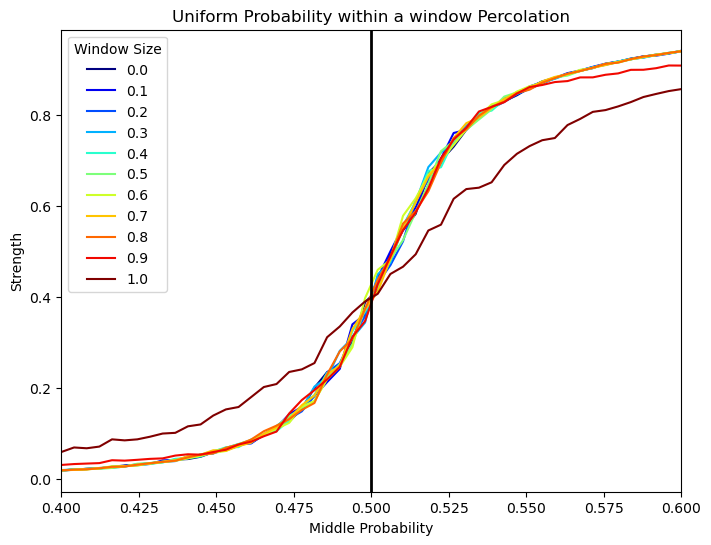

In [23]:
# plt.style.use("Physicist")
plt.figure(figsize=(8, 6))
plt.axvline(0.5, c="k", zorder=50, lw=2)
n = len(windows)
colors = plt.cm.jet(np.linspace(0, 1, n))
for idx in range(n):
    plt.plot(prob, lcc[idx], label=f"{windows[idx]*2:.1f}", c=colors[idx])
plt.legend(title="Window Size")
plt.title("Uniform Probability within a window Percolation")
plt.ylabel("Strength")
plt.xlabel("Middle Probability")
plt.xlim(0.4, 0.6)
# plt.savefig("test.png", dpi=300)

In [46]:
def dunno(graph, n_probs=100, copies=1000, low_p=0.4, high_p=0.6, no_bar=False):
    n_edges = g.ecount()
    lcc = np.zeros(n_probs, dtype="float32")
    all_prob = np.linspace(low_p, high_p, n_probs)
    for idx, p in tqdm(enumerate(all_prob), total=n_probs, disable=no_bar):
        is_removed = rng.random((copies, n_edges))
        link_prob = rng.uniform(p, 1, (copies, n_edges))
        links_removed = is_removed >= link_prob
        for rep in range(copies):
            links_to_remove = np.flatnonzero(links_removed[rep])
            work = graph.copy()
            work.delete_edges(links_to_remove)
            lcc[idx] += max(work.components().sizes())
            # lcc[idx] += work.components().size(0)
            # ANOTHER ORDER PARAMETER???
        lcc[idx] /= copies
    return all_prob, lcc / g.vcount()

In [62]:
prob, my_lcc = dunno(g, copies=10, low_p=0, high_p=1)

  0%|          | 0/100 [00:00<?, ?it/s]